# Pacotes

In [1]:
import pandas as pd
import numpy as np

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from prettytable import PrettyTable
import sklearn
from sklearn.metrics import confusion_matrix

import time
from tensorflow import keras
import tensorflow as tf
from keras.models import Sequential
from keras.models import Sequential
from keras.layers import Dense, LSTM, Bidirectional, Flatten #Global max pullin avg max pulling
from keras.layers import  Masking
from keras.regularizers import l2

from keras.callbacks import EarlyStopping, ModelCheckpoint

tf.config.list_physical_devices('GPU')

# fix random seed for reproducibility
seed = 42
tf.random.set_seed(seed)

2023-04-27 09:01:10.502582: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-04-27 09:01:10.559272: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-04-27 09:01:10.561207: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2023-04-27 09:01:10.561216: I tensorflow/compiler/xla/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudar

# Funcoes

In [2]:
##############################
###### Matriz de confusão ####
##############################

def matriz_confusao(y_real,y_predito,modelo):

### Grafico ###

  tabela=confusion_matrix(y_real,y_predito)

  group_names = ["True Neg","False Pos","False Neg","True Pos"]
  group_counts = ["{0:0.0f}".format(value) for value in
                tabela.flatten()]
  group_percentages = ["{0:.5%}".format(value) for value in
                     tabela.flatten()/np.sum(tabela)]
  labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]
  labels = np.asarray(labels).reshape(2,2)
  f = plt.figure()
  f.set_figwidth(8)
  f.set_figheight(8)

  sns.heatmap(tabela, annot=labels, fmt="", cmap='Blues')

### Tabela ###
  Resultados=PrettyTable()
  Resultados.field_names=["Métrica","Resultado"]
  Resultados.title= modelo
  Resultados.align["Métrica"]="l"
  Resultados.align["Resultado"]="r"

  Resultados.add_row(["Acurácia:",round(sklearn.metrics.accuracy_score(y_real,y_predito),2)])
  Resultados.add_row(["Precisão:",round(sklearn.metrics.precision_score(y_real,y_predito),2)])
  Resultados.add_row(["Recall:",round(sklearn.metrics.recall_score(y_real,y_predito),2)])
  Resultados.add_row(["F1-Score:",round(sklearn.metrics.f1_score(y_real,y_predito),2)])

  print(Resultados)
  
  return



    
def transformacao_estrutura(df):
    '''
    Extrai os atributos do dataframe pandas

    Params:
    -------
    df: dataframe de entrada

    Returns:
    par X, Y
    '''

    X = df[[
       'vintequatrohoras'
     ,'Altitude_numerica'
     ,'Declividade_numerica'
     ,'graurisc'
#     ,'lon_ocr'
#     ,'lat_ocr'
     ,'Orientacao_numerica'
     ,'Curv_Vertical_numerica'
#     ,'Curv_Horizontal_numerica'
     ,'Relevo_sombreado_numerico'
#     ,'Vegetacao_Natural_Dominante'                
     ,'Area_Antropica_Dominante'                   
#     ,'legenda_2_Pecuária (pastagens)'             
     ,'Floresta_Ombrofila_Densa'                   
#     ,'Formacao_Pioneira'                          
#     ,'Floresta_Ombrofila_Densa_Submontana'        
     ,'Influencia_urbana'                          
#     ,'Vegetacao_Secundaria'                       
#     ,'Argilossolo'                                
     ,'Gleissolo'                                  
#     ,'Argilossolo_Vermelho_Amarelo'               
#     ,'Gleissolo_Melanico'                         
     ,'Area_Urbana'                                
     ,'Unidades_de_Conservacao_Protecao_Integral'  
#     ,'Plano_de_Manejo'                            
     ,'flg_comunidades'                          
#     ,'flg_agricola'                               
#     ,'flg_exploracao_mineral'                     
#     ,'flg_rocha'                                  
     ,'flg_cobertura_vegetal'                      
#     ,'flg_afloramento_rochoso'                    
#     ,'flg_favela'                                 
#     ,'flg_ocupacao_desordenada'
           ]]
    


    
    Y = df[['ocorrencia']]
    
    n_tempo, n_coord = conta_tempos_e_coordenadas(df)
    
    X_transformado = X.to_numpy().astype(np.float32).reshape(n_tempo , n_coord, -1)
    Y_transformado = Y.to_numpy().astype(np.float32).reshape(n_tempo , n_coord, -1)
    
    return X_transformado, Y_transformado

    
def conta_tempos_e_coordenadas(df):
    '''
    Conta o número de tempos e coordenadas de um dataframe

    Params:
    -------
    df: dataframe com os atributos 'tempo', e 'n_coord'

    Returns:
    --------
    tupla número de tempos, número de coordenadas
    '''
    tempo = len(df['tempo'].unique())
    n_coord = len(df['n_coord'].unique())

    return tempo, n_coord


def calcula_sample_weight(df,peso):
    '''
    Calcula os pesos para as amostras de treinamento
    '''
    
    Y = df[['ocorrencia']]
    sample_weight_ = list(Y['ocorrencia'])
    
    series = pd.Series(sample_weight_)
    series = series*peso #3191848/613
    series = series+1
    series = series/(peso+1)
    
    sample_weight_ = np.array(list(series)).astype(np.float32)
    
    return sample_weight_
    

# Importacao dos dados

In [3]:
df = pd.read_csv('df_comp.csv')

In [4]:
df.replace(np.nan,-1, inplace=True)

In [5]:
df['tempo'] =  pd.to_datetime(df['tempo'])

In [6]:
df = df.sort_values(['tempo','n_coord'])

Manter fixo:

* Teste  - 3 meses

Deslizar:

* Treinamento - 2 anos

* Validação - 6 meses

In [7]:
treino = df[df.loc[:,'tempo'] <= pd.to_datetime('2021-02-24 09:00:00')]

In [8]:
filtro_inferior = pd.to_datetime('2021-02-24 09:00:00') < df.loc[:, 'tempo']
filtro_superior = df.loc[:, 'tempo'] <= pd.to_datetime('2021-08-24 09:00:00')
validacao = df[filtro_inferior & filtro_superior]

In [9]:
teste = df[df.loc[:,'tempo'] > pd.to_datetime('2021-08-24 09:00:00')]

In [10]:
### Treino

X_train, Y_train = transformacao_estrutura(treino)

### Validação

X_val, Y_val = transformacao_estrutura(validacao)

### Teste

X_teste, Y_teste = transformacao_estrutura(teste)

class_weight_ = {0: (1/3191848),
                1: (1/613)}

In [11]:
print('Treino')
qtd_o = sum(treino['ocorrencia'])
tam_o = len(treino['ocorrencia'])
print(qtd_o)
print(tam_o)
print(tam_o/qtd_o) #peso

print('Validação')
qtd_o = sum(validacao['ocorrencia'])
tam_o = len(validacao['ocorrencia'])
print(qtd_o)
print(tam_o)

print('Teste')
qtd_o = sum(teste['ocorrencia'])
tam_o = len(teste['ocorrencia'])
print(qtd_o)
print(tam_o)

Treino
284
1555500
5477.112676056338
Validação
3
384625
Teste
33
306000


In [12]:
sample_weight_ = np.asarray(calcula_sample_weight(treino,5600)).astype(np.float32)

In [13]:
print(sample_weight_.max())
print(sample_weight_.min())

1.0
0.00017853954


In [14]:
sample_weight_transformado = sample_weight_.reshape(len(treino['tempo'].unique()), len(treino['n_coord'].unique()), -1)

In [15]:
sample_weight_transformado.shape

(732, 2125, 1)

In [16]:
X_val.shape

(181, 2125, 15)

In [17]:
print(Y_train.shape)
print(X_train.shape)

(732, 2125, 1)
(732, 2125, 15)


In [19]:
X_train

array([[[-1.6094379e+00,  3.5240257e+00,  3.8144834e+00, ...,
          1.0000000e+00,  0.0000000e+00,  1.0000000e+00],
        [ 9.9999997e-06,  3.9632485e+00,  3.7411430e+00, ...,
          1.0000000e+00,  0.0000000e+00,  1.0000000e+00],
        [ 9.9999997e-06,  4.0188570e+00,  3.9687700e+00, ...,
          1.0000000e+00,  0.0000000e+00,  1.0000000e+00],
        ...,
        [ 9.9999997e-06,  4.6761074e+00,  2.9087219e+00, ...,
          0.0000000e+00,  1.0000000e+00,  0.0000000e+00],
        [ 9.9999997e-06,  3.2434185e+00,  7.7471977e-01, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        [ 9.9999997e-06,  4.1019115e+00,  3.2507536e+00, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00]],

       [[ 9.9999997e-06,  3.5240257e+00,  3.8144834e+00, ...,
          1.0000000e+00,  0.0000000e+00,  1.0000000e+00],
        [ 9.9999997e-06,  3.9632485e+00,  3.7411430e+00, ...,
          1.0000000e+00,  0.0000000e+00,  1.0000000e+00],
        [ 9.9999997e-06, 

In [18]:
time_step = X_train.shape[1] # Quantidade de coordenada para equivaler a 1 espaço de tempo
input_dim = X_train.shape[2] #qtd colunas (features)
out = Y_train.shape[2]

# LSTM
start = time.time()
model = Sequential()
model.add(Masking(mask_value=-1.,input_shape=(time_step, input_dim,))) #camada de entrada
model.add(LSTM(32,activation='elu', input_shape=(time_step, input_dim,),return_sequences=True, go_backwards=True
               , kernel_regularizer=l2(0.01), recurrent_regularizer=l2(0.01), bias_regularizer=l2(0.01))) # camada escondida
model.add(Dense(out, activation='sigmoid')) #camada saida

opt = tf.keras.optimizers.Adam(learning_rate=0.01)

model.compile(loss = tf.keras.losses.BinaryCrossentropy(from_logits=False) #https://keras.io/api/losses/probabilistic_losses/ 
              , optimizer= opt #'adam'
              , weighted_metrics=[tf.keras.losses.BinaryCrossentropy(from_logits=False),'accuracy'
              , tf.keras.metrics.Precision()
              , tf.keras.metrics.Recall()]
              , sample_weight_mode="temporal")   #Weights
model.summary()
hist = model.fit(X_train
                 , Y_train
                 , epochs=100
#                  , validation_split=.2
                 ,validation_data=(X_val, Y_val)
                 , verbose=1, batch_size=64
                 , sample_weight=sample_weight_transformado 
                 #(samples, sequence_length)
        )
end = time.time()
print("Total compile time: --------", end - start, 's')


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 masking (Masking)           (None, 2125, 15)          0         
                                                                 
 lstm (LSTM)                 (None, 2125, 32)          6144      
                                                                 
 dense (Dense)               (None, 2125, 1)           33        
                                                                 
Total params: 6,177
Trainable params: 6,177
Non-trainable params: 0
_________________________________________________________________


2023-04-27 00:16:47.763660: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Epoch 1/100
12/12 [==============================] - 6s 416ms/step - loss: nan - binary_crossentropy: nan - accuracy: 0.4760 - precision: 0.3497 - recall: 0.0423 - val_loss: nan - val_binary_crossentropy: nan - val_accuracy: 1.0000 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/100
12/12 [==============================] - 5s 382ms/step - loss: nan - binary_crossentropy: nan - accuracy: 0.4944 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_loss: nan - val_binary_crossentropy: nan - val_accuracy: 1.0000 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/100
12/12 [==============================] - 5s 374ms/step - loss: nan - binary_crossentropy: nan - accuracy: 0.4944 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_loss: nan - val_binary_crossentropy: nan - val_accuracy: 1.0000 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/100
12/12 [==============================] - 5s 385ms/step - loss: nan - binary_crossentropy: nan - accuracy: 0.4944 - pr

Epoch 29/100
12/12 [==============================] - 5s 396ms/step - loss: nan - binary_crossentropy: nan - accuracy: 0.4944 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_loss: nan - val_binary_crossentropy: nan - val_accuracy: 1.0000 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 30/100
12/12 [==============================] - 5s 394ms/step - loss: nan - binary_crossentropy: nan - accuracy: 0.4944 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_loss: nan - val_binary_crossentropy: nan - val_accuracy: 1.0000 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 31/100
12/12 [==============================] - 5s 387ms/step - loss: nan - binary_crossentropy: nan - accuracy: 0.4944 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_loss: nan - val_binary_crossentropy: nan - val_accuracy: 1.0000 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 32/100
12/12 [==============================] - 5s 398ms/step - loss: nan - binary_crossentropy: nan - accuracy:

Epoch 57/100
12/12 [==============================] - 5s 395ms/step - loss: nan - binary_crossentropy: nan - accuracy: 0.4944 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_loss: nan - val_binary_crossentropy: nan - val_accuracy: 1.0000 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 58/100
12/12 [==============================] - 5s 384ms/step - loss: nan - binary_crossentropy: nan - accuracy: 0.4944 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_loss: nan - val_binary_crossentropy: nan - val_accuracy: 1.0000 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 59/100
12/12 [==============================] - 5s 397ms/step - loss: nan - binary_crossentropy: nan - accuracy: 0.4944 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_loss: nan - val_binary_crossentropy: nan - val_accuracy: 1.0000 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 60/100
12/12 [==============================] - 5s 404ms/step - loss: nan - binary_crossentropy: nan - accuracy:

Epoch 85/100
12/12 [==============================] - 5s 378ms/step - loss: nan - binary_crossentropy: nan - accuracy: 0.4944 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_loss: nan - val_binary_crossentropy: nan - val_accuracy: 1.0000 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 86/100
12/12 [==============================] - 5s 401ms/step - loss: nan - binary_crossentropy: nan - accuracy: 0.4944 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_loss: nan - val_binary_crossentropy: nan - val_accuracy: 1.0000 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 87/100
12/12 [==============================] - 5s 400ms/step - loss: nan - binary_crossentropy: nan - accuracy: 0.4944 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_loss: nan - val_binary_crossentropy: nan - val_accuracy: 1.0000 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 88/100
12/12 [==============================] - 5s 408ms/step - loss: nan - binary_crossentropy: nan - accuracy:

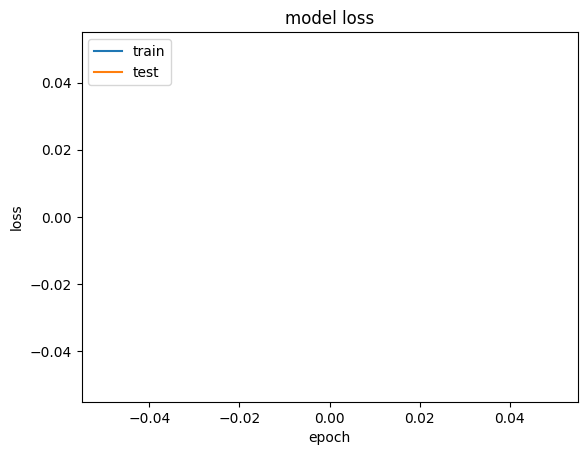

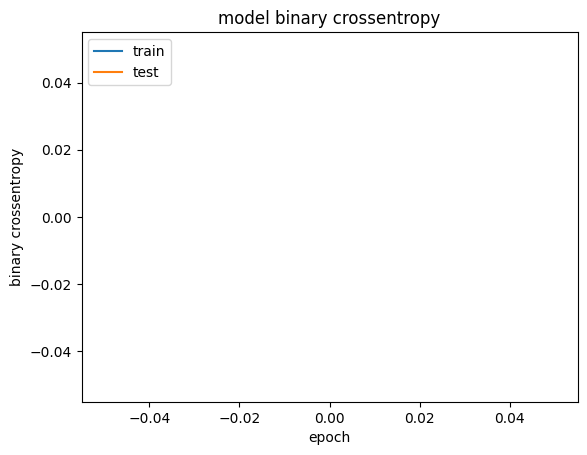

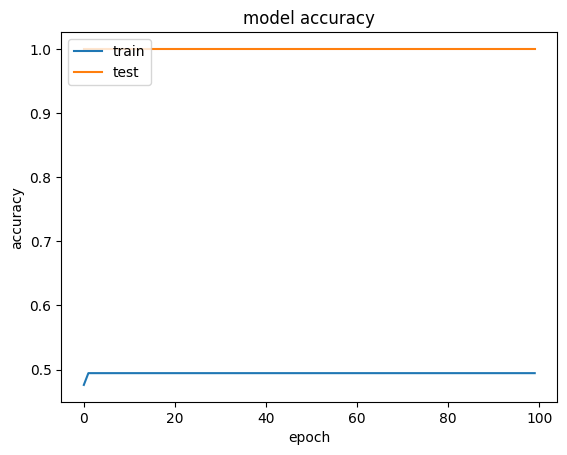

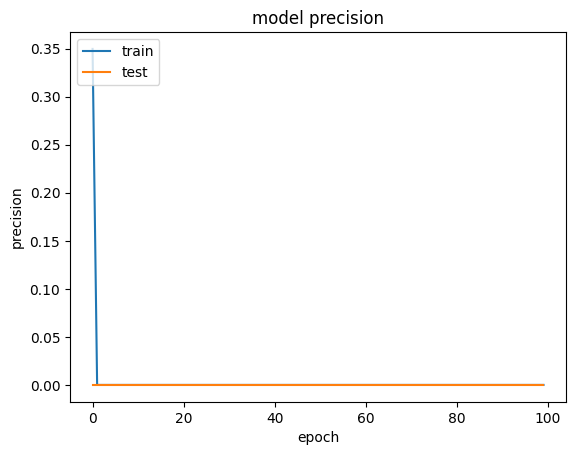

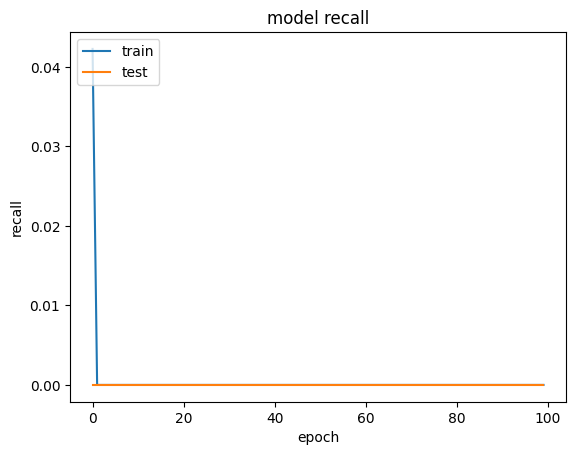

In [19]:
# summarize history for loss
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# summarize history for binary crossentropy
plt.plot(hist.history['binary_crossentropy'])
plt.plot(hist.history['val_binary_crossentropy'])
plt.title('model binary crossentropy')
plt.ylabel('binary crossentropy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()


# summarize history for accuracy
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# summarize history for precision
plt.plot(hist.history['precision'])
plt.plot(hist.history['val_precision'])
plt.title('model precision')
plt.ylabel('precision')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# summarize history for recall
plt.plot(hist.history['recall'])
plt.plot(hist.history['val_recall'])
plt.title('model recall')
plt.ylabel('recall')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [20]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 masking (Masking)           (None, 2125, 15)          0         
                                                                 
 lstm (LSTM)                 (None, 2125, 32)          6144      
                                                                 
 dense (Dense)               (None, 2125, 1)           33        
                                                                 
Total params: 6,177
Trainable params: 6,177
Non-trainable params: 0
_________________________________________________________________


In [21]:
predictions = (model.predict(X_teste, verbose=1) > 0.5).astype("int32").reshape((1,-1))

5/5 [==============================] - 0s 63ms/step


In [22]:
def flatten(l):
    return [item for sublist in l for item in sublist]

In [23]:
pred_y = pd.DataFrame(flatten(predictions), columns=['Prediction']) 

+-----------------------+
|           3           |
+-----------+-----------+
| Métrica   | Resultado |
+-----------+-----------+
| Acurácia: |       1.0 |
| Precisão: |       0.0 |
| Recall:   |       0.0 |
| F1-Score: |       0.0 |
+-----------+-----------+


/home/pdpa-chuvas/Deslizamento/env/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


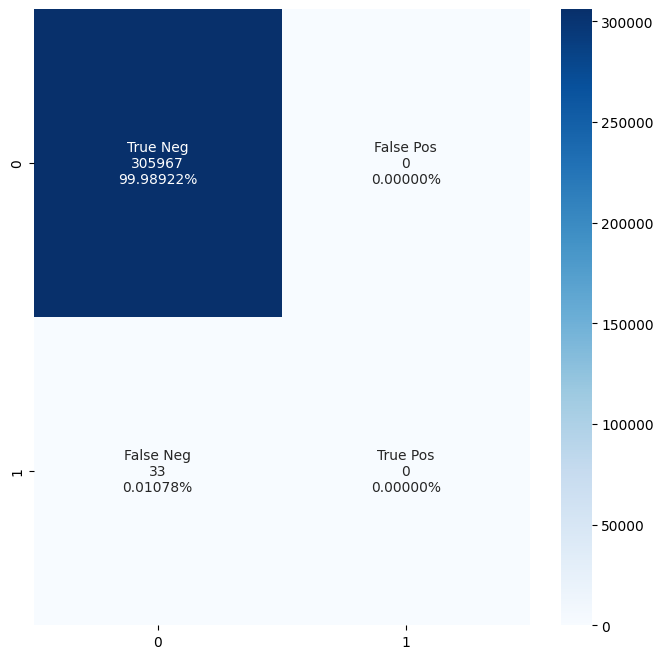

In [25]:
matriz_confusao(teste[['ocorrencia']],pred_y,'3')

In [27]:
bla = model.predict(X_teste, verbose=1)

5/5 [==============================] - 0s 61ms/step


In [29]:
bla.shape

(144, 2125, 1)